<a href="https://colab.research.google.com/github/ipm06aabhak-ai/ITA-assign-Aabha/blob/main/ppt%20lec2%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Google playstore apps.xlsx to Google playstore apps (2).xlsx
Dataset loaded: Google playstore apps (2).xlsx
Shape: (100, 14)


,index,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



Cleaned Data Preview


,App,Category,Rating,Installs,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,10000.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,500000.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,5000000.0,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,50000000.0,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,100000.0,0.0



Cluster counts:
Cluster
3    36
0    32
1    30
2     1
Name: count, dtype: int64


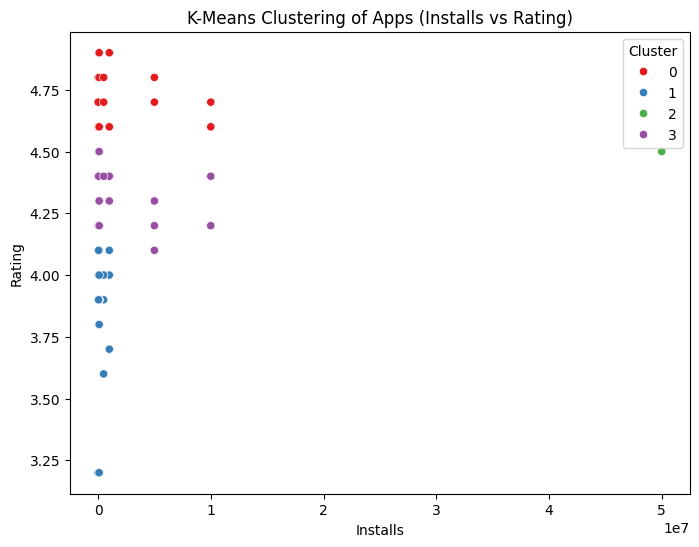


Model Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


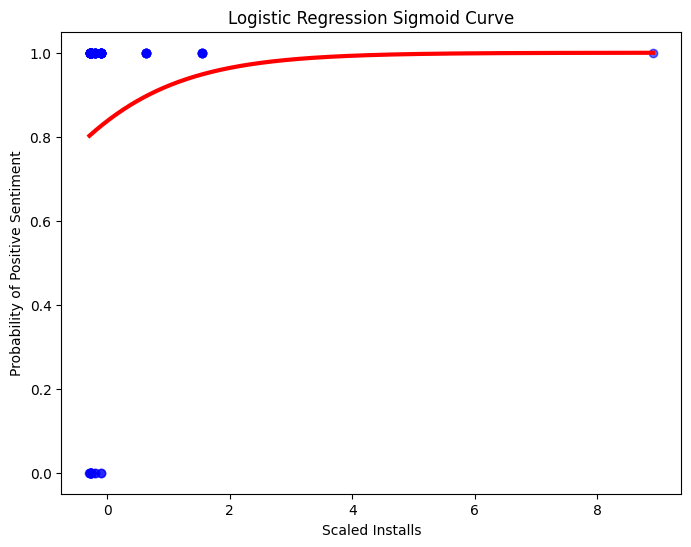


Key Insights:
• Apps naturally cluster based on installs, rating and price.
• Some highly downloaded apps do not always receive the best ratings.
• Logistic regression estimates the probability that an app will receive positive sentiment.
• The sigmoid curve visualizes how installs influence the likelihood of positive ratings.
• Developers should focus on improving user experience rather than relying only on downloads.


In [6]:
# ==============================
# Google Play Store Hybrid ML Analysis
# ==============================

!pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# 1. Upload Dataset
# ==============================

uploaded = files.upload()
filename = list(uploaded.keys())[0]

data = pd.read_excel(filename)

print("Dataset loaded:", filename)
print("Shape:", data.shape)

display(data.head())

# ==============================
# 2. Data Cleaning
# ==============================

data = data.dropna(subset=['Rating'])

data['Installs'] = data['Installs'].astype(str)
data['Installs'] = data['Installs'].str.replace('+','', regex=False)
data['Installs'] = data['Installs'].str.replace(',','', regex=False)
data['Installs'] = data['Installs'].astype(float)

data['Price'] = data['Price'].astype(str)
data['Price'] = data['Price'].str.replace('$','', regex=False)
data['Price'] = data['Price'].astype(float)

print("\nCleaned Data Preview")
display(data[['App','Category','Rating','Installs','Price']].head())

# ==============================
# 3. K-Means Clustering
# ==============================

features = data[['Rating','Installs','Price']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print("\nCluster counts:")
print(data['Cluster'].value_counts())

# ==============================
# 4. K-Means Visualization
# ==============================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data['Installs'],
    y=data['Rating'],
    hue=data['Cluster'],
    palette='Set1'
)

plt.title("K-Means Clustering of Apps (Installs vs Rating)")
plt.xlabel("Installs")
plt.ylabel("Rating")

plt.show()

# ==============================
# 5. Create Sentiment Variable
# ==============================

data['Sentiment'] = data['Rating'].apply(lambda x: 1 if x >= 4 else 0)

# ==============================
# 6. Scale Installs for Logistic Regression
# ==============================

scaler_lr = StandardScaler()

X = scaler_lr.fit_transform(data[['Installs']])
y = data['Sentiment']

# ==============================
# 7. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Logistic Regression Model
# ==============================

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# ==============================
# 9. Smooth Sigmoid Curve
# ==============================

X_range = np.linspace(X.min(), X.max(), 500).reshape(-1,1)

probabilities = model.predict_proba(X_range)[:,1]

plt.figure(figsize=(8,6))

# scatter actual data
plt.scatter(X, y, color='blue', alpha=0.6)

# sigmoid curve
plt.plot(X_range, probabilities, color='red', linewidth=3)

plt.title("Logistic Regression Sigmoid Curve")
plt.xlabel("Scaled Installs")
plt.ylabel("Probability of Positive Sentiment")

plt.show()

# ==============================
# 10. Insights
# ==============================

print("\nKey Insights:")
print("• Apps naturally cluster based on installs, rating and price.")
print("• Some highly downloaded apps do not always receive the best ratings.")
print("• Logistic regression estimates the probability that an app will receive positive sentiment.")
print("• The sigmoid curve visualizes how installs influence the likelihood of positive ratings.")
print("• Developers should focus on improving user experience rather than relying only on downloads.")